# Run Viewer
Change RUN_PATH to view any run.

In [ ]:
import json, sys, math
import matplotlib.pyplot as plt
sys.path.insert(0, "/home/jupyter-xcao/mwu")
from mw_lib import (
    load_data, get_case,
    check_weight_normalization, analyze_model_output,
    plot_regret_comparison, plot_weight_comparison, plot_cumulative_loss,
)
%matplotlib inline

# ── Change this to view a different run ──────────────────
RUN_PATH = "results/manual/train_000/run_000_004"
# ─────────────────────────────────────────────────────────

result = json.load(open(f"/home/jupyter-xcao/mwu/{RUN_PATH}/result.json"))

if "meta" in result:
    meta         = result["meta"]
    inp          = result["input"]
    model_output = result["response"]
    analysis     = result["analysis"]
else:
    parts     = RUN_PATH.rstrip("/").split("/")
    case_name = parts[-2]
    split, cidx = case_name.rsplit("_", 1)
    meta         = {"split": split, "idx": int(cidx), "run": parts[-1]}
    model_output = {k: result[k] for k in ["weights_sequence", "mixture_probabilities", "algorithm_predictions"]}
    analysis     = result
    inp          = None

data = load_data("/home/jupyter-xcao/mwu/mw_dataset.json")
case = get_case(data, meta["split"], meta["idx"])
if inp is None:
    inp = {"n": len(case["expert_predictions"][0]), "T": case["n_steps"],
           "eta": case["learning_rate"], "expert_predictions": case["expert_predictions"],
           "true_labels": case["true_labels"], "losses": case["losses"]}

print(f"split      : {meta['split']}")
print(f"case index : {meta['idx']}")
print(f"run        : {meta['run']}")
print(f"mode       : {meta.get('mode', 'manual')}")
print(f"n_steps    : {inp['T']}")
print(f"n_experts  : {inp['n']}")
print(f"eta        : {inp['eta']:.6f}")

## Case Input

In [21]:
print(json.dumps(inp, indent=2))

{
  "n": 4,
  "T": 50,
  "eta": 0.48443870807995715,
  "expert_predictions": [
    [
      1,
      1,
      1,
      1
    ],
    [
      0,
      0,
      0,
      0
    ],
    [
      1,
      1,
      0,
      1
    ],
    [
      1,
      1,
      0,
      0
    ],
    [
      0,
      1,
      1,
      0
    ],
    [
      0,
      1,
      1,
      0
    ],
    [
      0,
      0,
      0,
      1
    ],
    [
      0,
      1,
      1,
      0
    ],
    [
      0,
      0,
      0,
      1
    ],
    [
      0,
      0,
      0,
      1
    ],
    [
      0,
      0,
      1,
      1
    ],
    [
      1,
      1,
      0,
      0
    ],
    [
      1,
      1,
      0,
      1
    ],
    [
      1,
      1,
      0,
      0
    ],
    [
      1,
      1,
      0,
      1
    ],
    [
      0,
      0,
      1,
      0
    ],
    [
      1,
      1,
      0,
      0
    ],
    [
      0,
      0,
      0,
      1
    ],
    [
      0,
      1,
      0,
      0
    ],
    [
   

## Weight Normalization

In [22]:
norm = check_weight_normalization(model_output)
print("All normalized :", norm["all_normalized"])
print("Max deviation  :", f"{norm['max_deviation']:.2e}")
if norm["bad_steps"]:
    print("Bad steps      :", norm["bad_steps"][:10])


All normalized : False
Max deviation  : 1.07e-04
Bad steps      : [(25, 0.99990435), (26, 0.99989251), (27, 0.9999), (28, 0.9999)]


## Correctness Summary

In [ ]:
w = analysis["weights"]
p = analysis["mixture_probabilities"]
y = analysis["algorithm_predictions"]

print(f"weights.check_norm    : {w['check_norm']}")
print(f"weights.mean_ell1     : {w['mean_ell1']:.4f}  std={w['std_ell1']:.4f}")
print(f"weights.ell1_per_step : {[round(x,4) for x in w['ell1_per_step']]}")
print()
print(f"prob.check_compute    : {p['check_compute']}")
print(f"prob.mean_abs_error   : {p['mean_abs_error']:.4f}  std={p['std_abs_error']:.4f}")
print(f"prob.abs_err_per_step : {[round(x,4) for x in p['abs_err_per_step']]}")
print()
print(f"pred.check_pred       : {y['check_pred']}")
print(f"pred.accuracy         : {y['accuracy']:.3f}")
print(f"pred.model_regret     : {[round(x,4) for x in y['model_regret']]}")
print(f"pred.true_regret      : {[round(x,4) for x in y['true_regret']]}")

## Regret Comparison

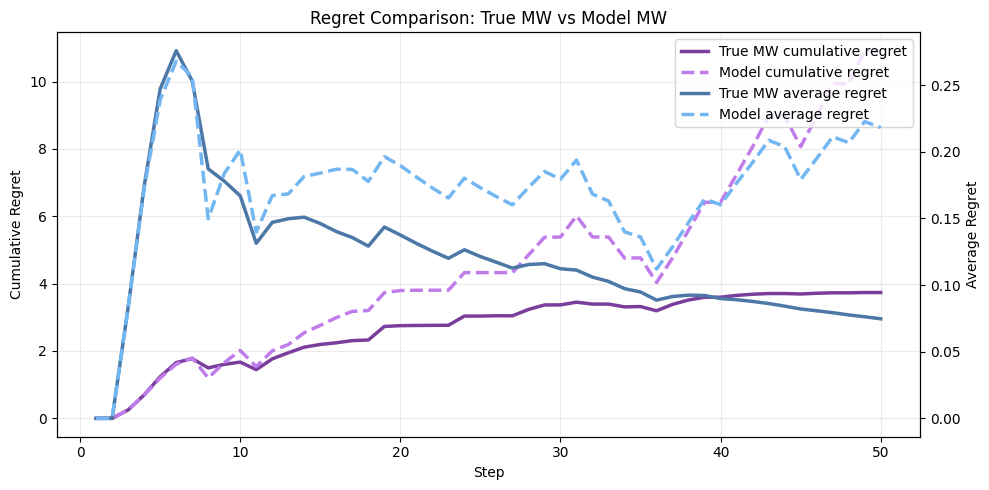

In [24]:
plot_regret_comparison(case, model_output)

## Weight Comparison

In [ ]:
plot_weight_comparison(case, model_output)

## Cumulative Loss

In [ ]:
plot_cumulative_loss(analysis, case=case, model_output=model_output)